In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [5]:
# read in all the words
words = open("D:/Neural Networks/Bigram/names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [8]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [11]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

0/200000:  20.84372901916504
10000/200000:  2.3628928661346436
20000/200000:  2.8754968643188477
30000/200000:  2.701333999633789
40000/200000:  2.9104626178741455
50000/200000:  2.6274726390838623
60000/200000:  2.7223803997039795
70000/200000:  2.4282631874084473
80000/200000:  1.9347164630889893
90000/200000:  2.342893600463867
100000/200000:  2.66810941696167
110000/200000:  1.6423823833465576
120000/200000:  2.029299736022949
130000/200000:  2.2737326622009277
140000/200000:  1.9090875387191772
150000/200000:  2.2399675846099854
160000/200000:  2.186823844909668
170000/200000:  2.264503002166748
180000/200000:  2.284435272216797
190000/200000:  2.244933843612671


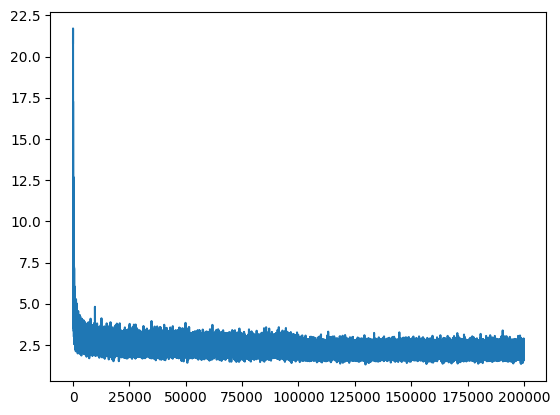

In [12]:
plt.plot(lossi)

In [13]:
@torch.no_grad() # disable graident tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.139573335647583
val 2.183924674987793


In [14]:
for _ in range(20):
    prev = torch.zeros((1, block_size), dtype=torch.long)
    chars = []
    while True:
        emb = C[prev]
        h = torch.tanh(emb.view((-1, block_size * n_emb)) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)

        next_ix = torch.multinomial(prob, num_samples=1).item()

        if next_ix == 0:
            break

        chars.append(itos[next_ix])

        prev = torch.cat([
            prev[:, 1:],
            torch.tensor([[next_ix]])
        ], dim=1)

    print(''.join(chars))

zelo
joai
seih
elian
lolyn
kokinstiana
andy
zeer
arlynn
pzeon
dani
machestor
kaod
mahlin
rhylen
lecia
julia
kaylel
legelynn
xrric


**Handling Initializations**

In [24]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [25]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # break

      0/ 200000: 3.2547
  10000/ 200000: 1.8530
  20000/ 200000: 2.6639
  30000/ 200000: 2.5649
  40000/ 200000: 2.6366
  50000/ 200000: 2.0579
  60000/ 200000: 2.5871
  70000/ 200000: 2.1456
  80000/ 200000: 1.9427
  90000/ 200000: 2.1065
 100000/ 200000: 2.5290
 110000/ 200000: 1.6184
 120000/ 200000: 1.9472
 130000/ 200000: 2.3705
 140000/ 200000: 1.7652
 150000/ 200000: 1.9469
 160000/ 200000: 2.0796
 170000/ 200000: 2.3536
 180000/ 200000: 2.2487
 190000/ 200000: 2.3548


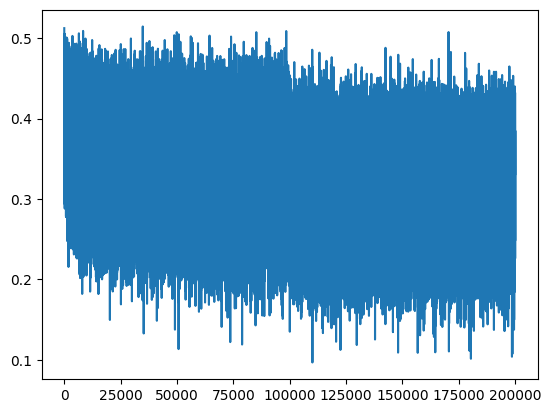

In [26]:
plt.plot(lossi)

In [27]:
@torch.no_grad() # disable graident tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.0634331703186035
val 2.124063491821289


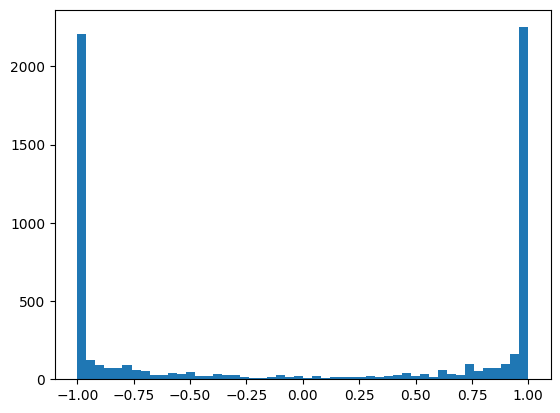

In [33]:
## checking the distribution of h and hpreact

plt.hist(h.view(-1).tolist(), 50);

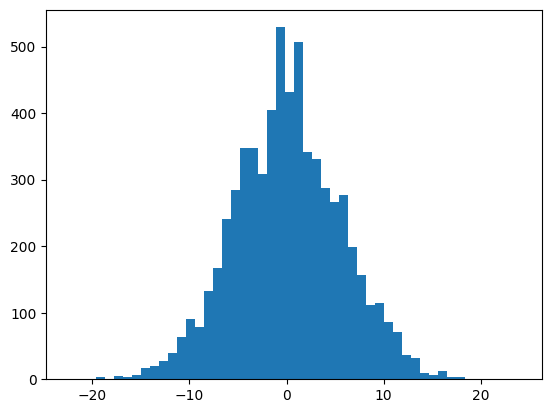

In [34]:
plt.hist(hpreact.view(-1).tolist(), 50);

**We see in h most of the values are saturated and in hpreact it is very wide**

**If we remember in backprod self.grad += (1-t^2) * out.grad**

***So if t is very close to -1 or 1 we are just killing the gradient as 1 - (1)^2 = 0..so it will be a dead neuron it will not learn anything as gradients are not getting propagated from the loss***

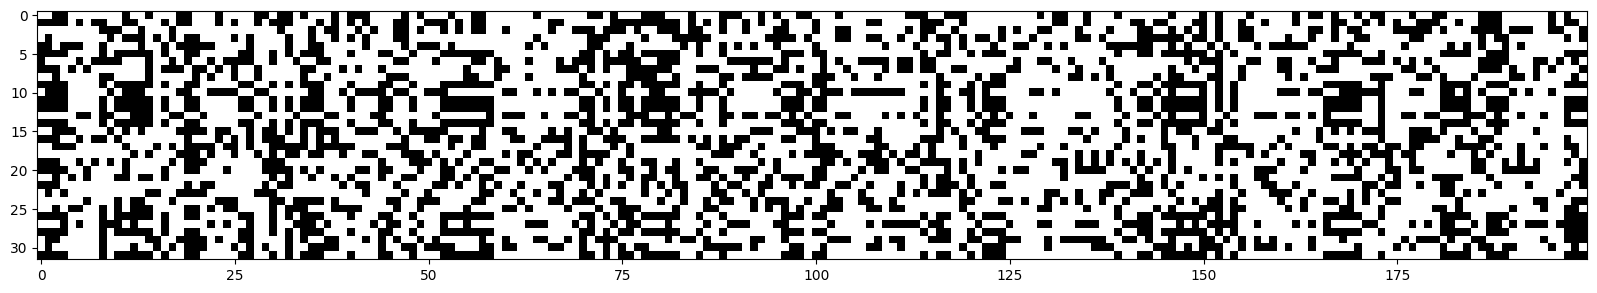

In [43]:
## we will see the stauration more intiutively

plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest") # we see all white weights are saturated and will be dead if any columns are all whites

**We will tone down the W1, b1 and check for saturations**

In [44]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden, generator=g) * 0.0
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [45]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    break

      0/ 200000: 3.2771


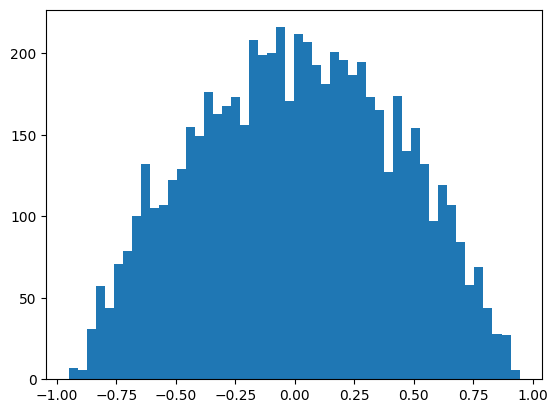

In [51]:
## checking the distribution of h and hpreact

plt.hist(h.view(-1).tolist(), 50); # now the distribution looks very gaussian

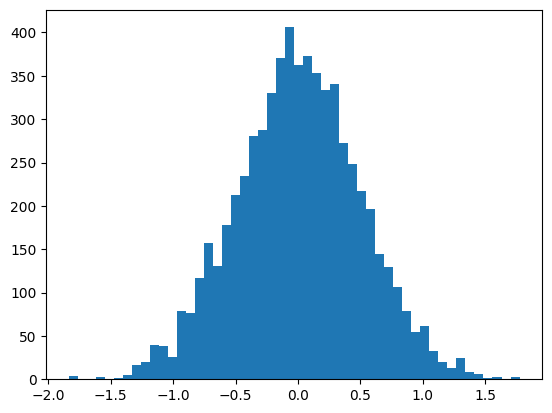

In [52]:
plt.hist(hpreact.view(-1).tolist(), 50); # the ranges are also good

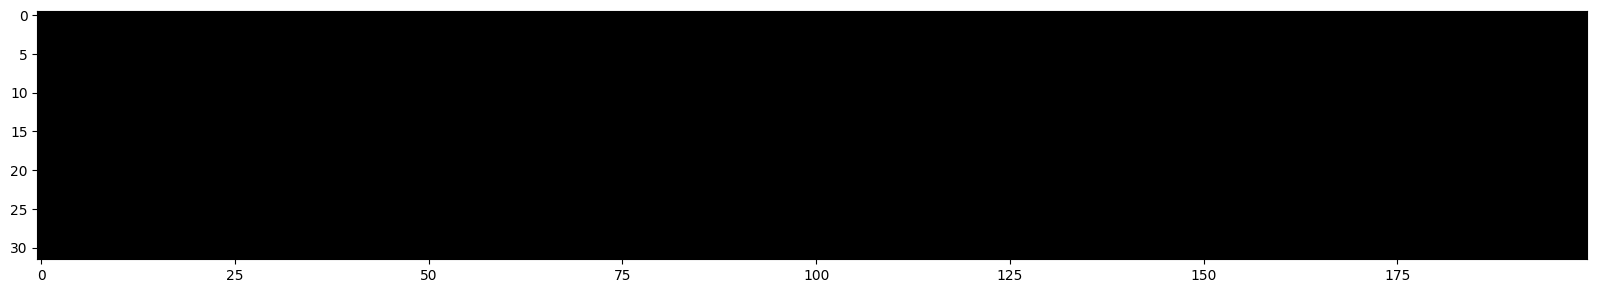

In [50]:
## we will see the stauration more intiutively

plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest") # we see all white weights are saturated and will be dead if any columns are all whites

In [53]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # break

      0/ 200000: 3.2638
  10000/ 200000: 2.2635
  20000/ 200000: 2.2693
  30000/ 200000: 2.2531
  40000/ 200000: 2.2115
  50000/ 200000: 2.1090
  60000/ 200000: 2.7616
  70000/ 200000: 1.9219
  80000/ 200000: 2.5294
  90000/ 200000: 2.3882
 100000/ 200000: 2.2508
 110000/ 200000: 1.4324
 120000/ 200000: 2.0515
 130000/ 200000: 1.8632
 140000/ 200000: 2.3869
 150000/ 200000: 2.1685
 160000/ 200000: 2.3465
 170000/ 200000: 1.9049
 180000/ 200000: 2.1476
 190000/ 200000: 2.1040


In [55]:
## again training with better initializations

@torch.no_grad() # disable graident tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.063537359237671
val 2.116687536239624


**We just used some random magic numbers to tone done the weights, is there any good number how do we know?**

***So lets analyse by a distributions of inputs and the outputs from a layer***

tensor(-0.0062) tensor(1.0013)
tensor(0.0089) tensor(3.1790)


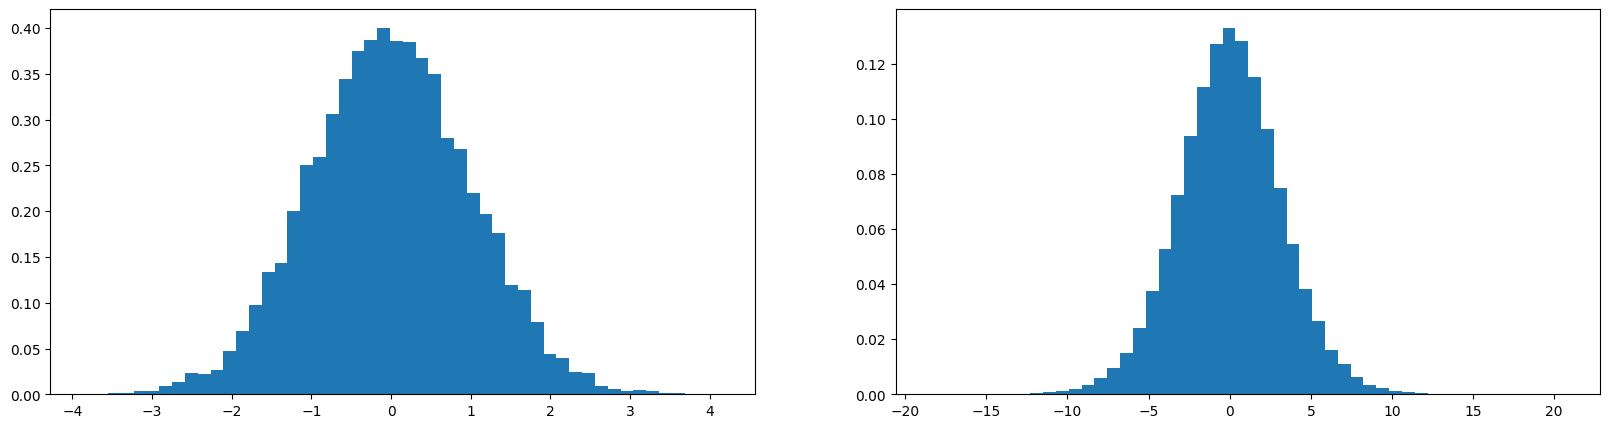

In [59]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w

print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

***We see we increased the standard deviation of the inputs and broaden the distribution this we dont want as discussed earlier this will potentially make neurons dead if they take extreme values and be in the flat regions of activation***

**How do we fix this?**
***Looks like we can multiply 1/sqrt(fan_in) to the intialization and by this the output distribution std will not change***

tensor(0.0020) tensor(1.0051)
tensor(-0.0004) tensor(0.9996)


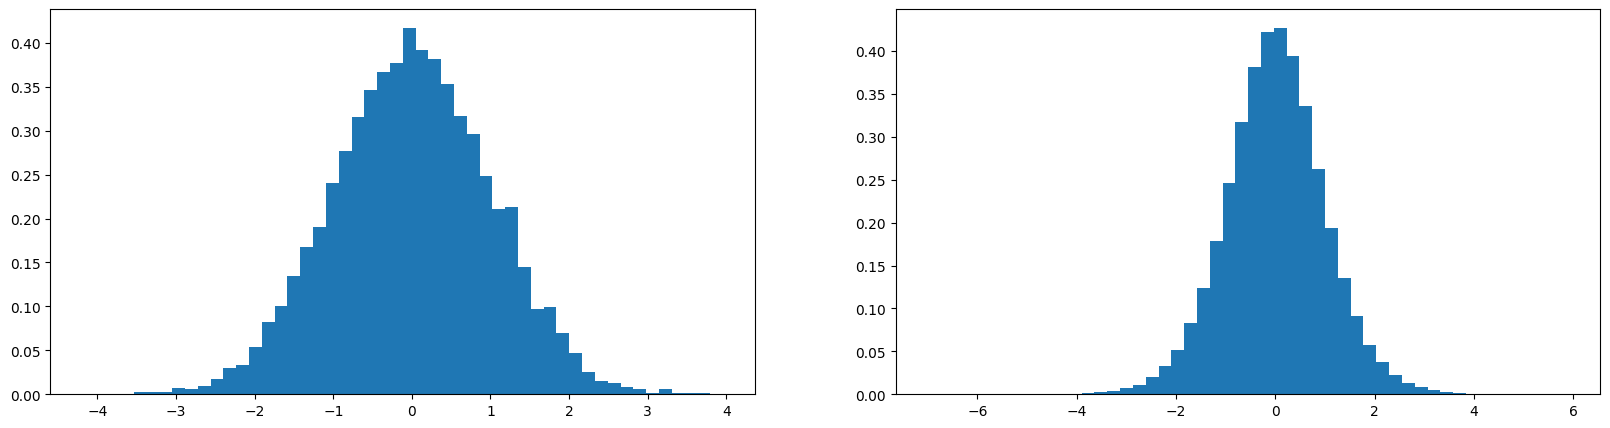

In [61]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * (1 / 10**0.5)
y = x @ w

print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True); # we see std is 1 for both input and outputs

***Now this init works fine for linear case, but for non linear activations like ReLu and Tanh, if we see they squashes the inputs to them into some regions***

****In relu all elements less then 0 is mapped to 0, and in tanh we have values between -1 to 1..so what does it mean?****


***It means we are decreasing the variance of the distribution, which we dont want so we compensation it usally with a gain for tanh gain is 5/3 and for relu it sqrt(2)***
***Check Kaiming Normal for more info***

In [67]:
# using appropriate init now

n_emb = 10
n_hidden = 200
gain = 5/3

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * gain * (1 / (block_size * n_emb) ** 0.5) # added gain as we will have tanh
b1 = torch.randn(n_hidden, generator=g) * 0.0
W2 = torch.randn((n_hidden, vocab_size), generator=g) * (1 / n_hidden ** 0.5) # no gain required as linear layer
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [68]:
# lets train

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # break

      0/ 200000: 3.2546
  10000/ 200000: 1.8511
  20000/ 200000: 2.6191
  30000/ 200000: 2.5536
  40000/ 200000: 2.5523
  50000/ 200000: 2.0505
  60000/ 200000: 2.3518
  70000/ 200000: 2.1808
  80000/ 200000: 1.9261
  90000/ 200000: 2.1365
 100000/ 200000: 2.3145
 110000/ 200000: 1.5586
 120000/ 200000: 1.8900
 130000/ 200000: 2.1650
 140000/ 200000: 1.7894
 150000/ 200000: 2.0932
 160000/ 200000: 2.0538
 170000/ 200000: 2.2754
 180000/ 200000: 2.1129
 190000/ 200000: 2.3414


In [69]:
split_loss("train")
split_loss("val")

train 2.0415468215942383
val 2.106959342956543


***This scaling of approach works for simple Neural networks where we just have sequential connections, if we have say skip conenctions like in ResNET. The choice of this gains is not possible and cannot be generalized. So how do we handle this? So we ensure that our activations will be roughly Gaussian***


***The answer is if we want them to be gaussian then we can just normalize the activations.***

***This is called Batch Normalizations and it works very well and it doesnot require this manual gains and init of weights as we will normalize the activations***

In [81]:
# using appropriate init now and adding BN parametes

n_emb = 10
n_hidden = 200
gain = 5/3

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * gain * (1 / (block_size * n_emb) ** 0.5) # added gain as we will have tanh
# b1 = torch.randn(n_hidden, generator=g) * 0.0 # BN normalizes hence we dont need bias as BN also has its own bias
W2 = torch.randn((n_hidden, vocab_size), generator=g) * (1 / n_hidden ** 0.5) # no gain required as linear layer
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12097


In [82]:
# we will add Batch norm here

max_steps = 200000
batch_size = 32
lossi = []
epsilon = 1e-5

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 

    # BN
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True) + epsilon) + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # break

      0/ 200000: 3.5151
  10000/ 200000: 2.1827
  20000/ 200000: 2.5456
  30000/ 200000: 2.1163
  40000/ 200000: 2.2217
  50000/ 200000: 2.0336
  60000/ 200000: 2.2219
  70000/ 200000: 2.1920
  80000/ 200000: 1.8170
  90000/ 200000: 1.8781
 100000/ 200000: 1.8281
 110000/ 200000: 2.2476
 120000/ 200000: 2.4234
 130000/ 200000: 2.4241
 140000/ 200000: 1.7641
 150000/ 200000: 1.9096
 160000/ 200000: 1.8910
 170000/ 200000: 2.1965
 180000/ 200000: 2.4299
 190000/ 200000: 1.8631


In [83]:
## again training with better initializations

@torch.no_grad() # disable graident tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True) + epsilon) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.069852352142334
val 2.1134896278381348


***Now if we see we are using mean and std of a batch, but how will it work on inference for single example?***

***The answer is we calculate running mean during the training and then we fix this and used in inference, so we Batch Normalizations introduces two non trainiable params which are running mean and bias***

In [84]:
# using appropriate init now and adding BN parametes

n_emb = 10
n_hidden = 200
gain = 5/3

g = torch.Generator().manual_seed(69)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * gain * (1 / (block_size * n_emb) ** 0.5) # added gain as we will have tanh
# b1 = torch.randn(n_hidden, generator=g) * 0.0 # BN normalizes hence we dont need bias as BN also has its own bias
W2 = torch.randn((n_hidden, vocab_size), generator=g) * (1 / n_hidden ** 0.5) # no gain required as linear layer
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12097


In [85]:
# we will add Batch norm here

max_steps = 200000
batch_size = 32
lossi = []
epsilon = 1e-5
alpha = 0.99 # momentum of BN

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 

    # BN
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + epsilon) + bnbias

    with torch.no_grad():
        bnmean_running = alpha * bnmean_running + (1 - alpha) * bnmeani
        bnstd_running = alpha * bnstd_running + (1 - alpha) * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # break

      0/ 200000: 3.5151
  10000/ 200000: 2.1827
  20000/ 200000: 2.5456
  30000/ 200000: 2.1163
  40000/ 200000: 2.2217
  50000/ 200000: 2.0336
  60000/ 200000: 2.2219
  70000/ 200000: 2.1920
  80000/ 200000: 1.8170
  90000/ 200000: 1.8781
 100000/ 200000: 1.8281
 110000/ 200000: 2.2476
 120000/ 200000: 2.4234
 130000/ 200000: 2.4241
 140000/ 200000: 1.7641
 150000/ 200000: 1.9096
 160000/ 200000: 1.8910
 170000/ 200000: 2.1965
 180000/ 200000: 2.4299
 190000/ 200000: 1.8631


In [87]:
@torch.no_grad() # disable gradient tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(-1, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / (bnstd_running + epsilon) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.070033311843872
val 2.113816738128662
